✓ tensorflow already installed
✓ matplotlib already installed
Installing scikit-learn...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: (54000, 28, 28, 1), Validation: (6000, 28, 28, 1), Test: (10000, 28, 28, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


LR=0.001 -> Val accuracy: 0.9883
LR=0.0005 -> Val accuracy: 0.9863
LR=0.0001 -> Val accuracy: 0.9618


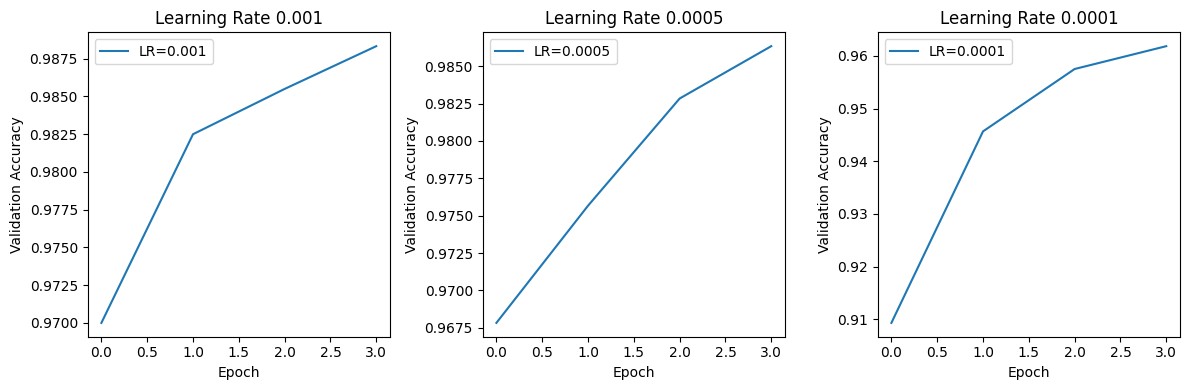

Filters Small [16, 32] -> Val acc: 0.9818
Filters Medium [32, 64] -> Val acc: 0.9875
Filters Large [48, 96] -> Val acc: 0.9882


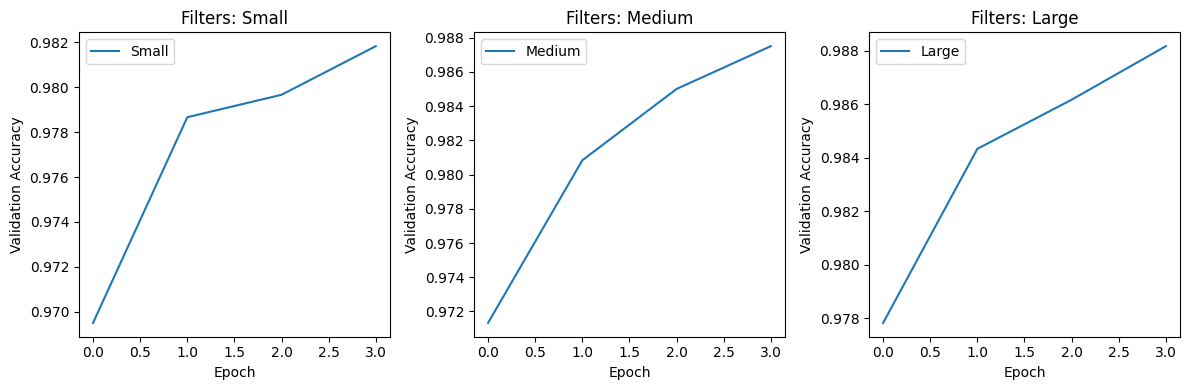

Optimizer Adam -> Val acc: 0.9887
Optimizer SGD -> Val acc: 0.9813
Optimizer RMSprop -> Val acc: 0.9868


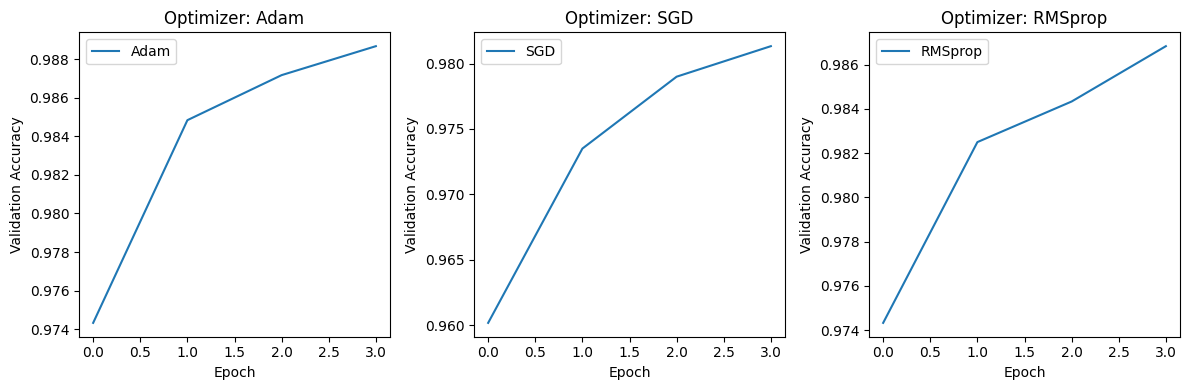

Dropout 0.3 -> Val acc: 0.9880
Dropout 0.5 -> Val acc: 0.9882
Dropout 0.7 -> Val acc: 0.9807


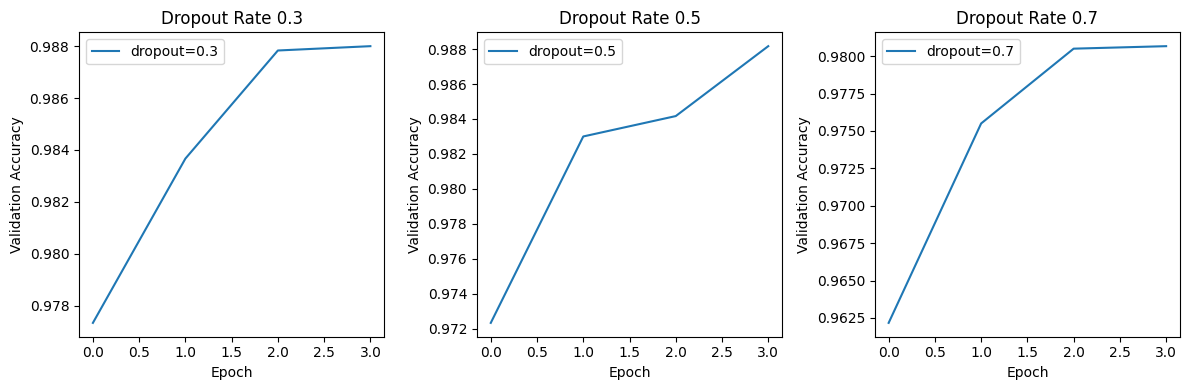

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 28s 28ms/step - accuracy: 0.7714 - loss: 0.7056 - val_accuracy: 0.9773 - val_loss: 0.0798
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - accuracy: 0.9019 - loss: 0.3176 - val_accuracy: 0.9845 - val_loss: 0.0549
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - accuracy: 0.9256 - loss: 0.2457 - val_accuracy: 0.9855 - val_loss: 0.0469
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - accuracy: 0.9368 - loss: 0.2078 - val_accuracy: 0.9873 - val_loss: 0.0423
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - accuracy: 0.9437 - loss: 0.1892 - val_accuracy: 0.9873 - val_loss: 0.0393
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - accuracy: 0.9485 - loss: 0.1727 - val_accuracy: 0.9885 - val_loss: 0.0349
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - accuracy: 0.9530 - loss: 0.1603 - val_accuracy: 0.9895 - val_loss: 0.0328
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - accuracy: 0.9559 - loss: 0.1529 - 

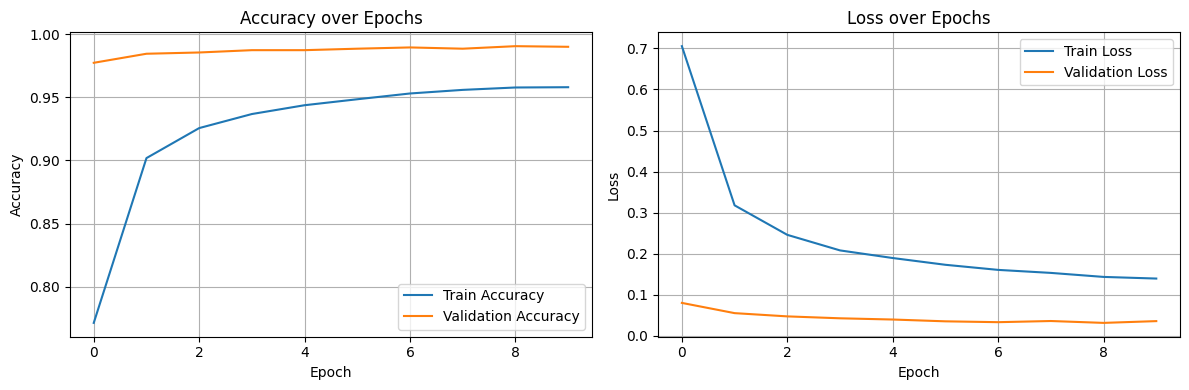

In [1]:
# =========================================
# INSTALL REQUIRED LIBRARIES
# =========================================

import subprocess
import sys
import importlib
import gc
import os

def install_if_missing(package):
    try:
        importlib.import_module(package)
        print(f"✓ {package} already installed")
    except ImportError:
        print(f"Installing {package}...")
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", package]
        )

install_if_missing("tensorflow")
install_if_missing("matplotlib")
install_if_missing("scikit-learn")


# =========================================
# IMPORT LIBRARIES
# =========================================

import tensorflow as tf

from tensorflow.keras import datasets, layers, models

from tensorflow.keras.optimizers import (
    Adam,
    SGD,
    RMSprop
)

from tensorflow.keras.layers import (
    Dropout,
    BatchNormalization
)

from tensorflow.keras.preprocessing.image import (
    ImageDataGenerator
)

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import numpy as np


# =========================================
# CLEAR PREVIOUS SESSION
# =========================================

tf.keras.backend.clear_session()
gc.collect()


# =========================================
# LOAD MNIST DATASET
# =========================================

(train_images, train_labels), (test_images, test_labels) = datasets.mnist.load_data()


# =========================================
# NORMALIZE IMAGES
# =========================================

train_images = train_images / 255.0
test_images = test_images / 255.0


# =========================================
# RESHAPE IMAGES
# =========================================

train_images = train_images.reshape(-1, 28, 28, 1)
test_images = test_images.reshape(-1, 28, 28, 1)


# =========================================
# TRAIN VALIDATION SPLIT
# =========================================

train_images, val_images, train_labels, val_labels = train_test_split(
    train_images,
    train_labels,
    test_size=0.1,
    random_state=42
)

print(
    f"Train: {train_images.shape}, "
    f"Validation: {val_images.shape}, "
    f"Test: {test_images.shape}"
)


# =========================================
# CNN MODEL FUNCTION
# =========================================

def build_small_cnn(
    filter_sizes=[32, 64],
    dropout_rate=0.5
):

    model = models.Sequential()

    # First Convolution Layer
    model.add(
        layers.Conv2D(
            filter_sizes[0],
            (3, 3),
            activation='relu',
            input_shape=(28, 28, 1)
        )
    )

    # First Pooling Layer
    model.add(
        layers.MaxPooling2D((2, 2))
    )

    # Second Convolution Layer
    model.add(
        layers.Conv2D(
            filter_sizes[1],
            (3, 3),
            activation='relu'
        )
    )

    # Second Pooling Layer
    model.add(
        layers.MaxPooling2D((2, 2))
    )

    # Flatten Layer
    model.add(layers.Flatten())

    # Dropout Layer
    model.add(
        Dropout(dropout_rate)
    )

    # Dense Layer
    model.add(
        layers.Dense(
            64,
            activation='relu'
        )
    )

    # Second Dropout
    model.add(
        Dropout(dropout_rate)
    )

    # Output Layer
    model.add(
        layers.Dense(
            10,
            activation='softmax'
        )
    )

    return model


# =========================================
# CLEAR MEMORY FUNCTION
# =========================================

def clear_memory():

    tf.keras.backend.clear_session()

    gc.collect()


# =========================================
# LEARNING RATE EXPERIMENT
# =========================================

learning_rates = [0.001, 0.0005, 0.0001]

val_accs_lr = []

plt.figure(figsize=(12, 4))

for i, lr in enumerate(learning_rates):

    clear_memory()

    model = build_small_cnn()

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        train_images,
        train_labels,
        validation_data=(val_images, val_labels),
        epochs=4,
        batch_size=128,
        verbose=0
    )

    best_val = max(history.history['val_accuracy'])

    val_accs_lr.append(best_val)

    print(f"LR={lr} -> Val accuracy: {best_val:.4f}")

    plt.subplot(1, 3, i + 1)

    plt.plot(
        history.history['val_accuracy'],
        label=f'LR={lr}'
    )

    plt.title(f'Learning Rate {lr}')

    plt.xlabel('Epoch')

    plt.ylabel('Validation Accuracy')

    plt.legend()

    del model, history

    clear_memory()

plt.tight_layout()
plt.show()


# =========================================
# FILTER SIZE EXPERIMENT
# =========================================

filter_configs = {
    'Small': [16, 32],
    'Medium': [32, 64],
    'Large': [48, 96]
}

val_accs_filters = []

plt.figure(figsize=(12, 4))

for i, (name, filters) in enumerate(filter_configs.items()):

    clear_memory()

    model = build_small_cnn(
        filter_sizes=filters
    )

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        train_images,
        train_labels,
        validation_data=(val_images, val_labels),
        epochs=4,
        batch_size=128,
        verbose=0
    )

    best_val = max(history.history['val_accuracy'])

    val_accs_filters.append(best_val)

    print(
        f"Filters {name} {filters} "
        f"-> Val acc: {best_val:.4f}"
    )

    plt.subplot(1, 3, i + 1)

    plt.plot(
        history.history['val_accuracy'],
        label=name
    )

    plt.title(f'Filters: {name}')

    plt.xlabel('Epoch')

    plt.ylabel('Validation Accuracy')

    plt.legend()

    del model, history

    clear_memory()

plt.tight_layout()
plt.show()


# =========================================
# OPTIMIZER EXPERIMENT
# =========================================

optimizers_dict = {

    'Adam': Adam(learning_rate=0.001),

    'SGD': SGD(
        learning_rate=0.01,
        momentum=0.9
    ),

    'RMSprop': RMSprop(
        learning_rate=0.001
    )
}

val_accs_opt = []

plt.figure(figsize=(12, 4))

for i, (opt_name, opt) in enumerate(optimizers_dict.items()):

    clear_memory()

    model = build_small_cnn()

    model.compile(
        optimizer=opt,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        train_images,
        train_labels,
        validation_data=(val_images, val_labels),
        epochs=4,
        batch_size=128,
        verbose=0
    )

    best_val = max(history.history['val_accuracy'])

    val_accs_opt.append(best_val)

    print(
        f"Optimizer {opt_name} "
        f"-> Val acc: {best_val:.4f}"
    )

    plt.subplot(1, 3, i + 1)

    plt.plot(
        history.history['val_accuracy'],
        label=opt_name
    )

    plt.title(f'Optimizer: {opt_name}')

    plt.xlabel('Epoch')

    plt.ylabel('Validation Accuracy')

    plt.legend()

    del model, history

    clear_memory()

plt.tight_layout()
plt.show()


# =========================================
# DROPOUT EXPERIMENT
# =========================================

dropout_rates = [0.3, 0.5, 0.7]

val_accs_drop = []

plt.figure(figsize=(12, 4))

for i, dr in enumerate(dropout_rates):

    clear_memory()

    model = build_small_cnn(
        dropout_rate=dr
    )

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        train_images,
        train_labels,
        validation_data=(val_images, val_labels),
        epochs=4,
        batch_size=128,
        verbose=0
    )

    best_val = max(history.history['val_accuracy'])

    val_accs_drop.append(best_val)

    print(
        f"Dropout {dr} "
        f"-> Val acc: {best_val:.4f}"
    )

    plt.subplot(1, 3, i + 1)

    plt.plot(
        history.history['val_accuracy'],
        label=f'dropout={dr}'
    )

    plt.title(f'Dropout Rate {dr}')

    plt.xlabel('Epoch')

    plt.ylabel('Validation Accuracy')

    plt.legend()

    del model, history

    clear_memory()

plt.tight_layout()
plt.show()


# =========================================
# FINAL MODEL TRAINING
# =========================================

clear_memory()

# Data Augmentation
datagen = ImageDataGenerator(

    rotation_range=10,

    zoom_range=0.1,

    width_shift_range=0.1,

    height_shift_range=0.1
)

datagen.fit(train_images)

# Final Model
final_model = build_small_cnn(
    filter_sizes=[32, 64],
    dropout_rate=0.5
)

final_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train Final Model
history_final = final_model.fit(

    datagen.flow(
        train_images,
        train_labels,
        batch_size=64
    ),

    epochs=10,

    validation_data=(
        val_images,
        val_labels
    ),

    verbose=1
)


# =========================================
# TEST EVALUATION
# =========================================

test_loss, test_acc = final_model.evaluate(
    test_images,
    test_labels,
    verbose=1
)

print(f"\nTest Accuracy: {test_acc:.4f}")


# =========================================
# PLOT TRAINING CURVES
# =========================================

plt.figure(figsize=(12, 4))

# Accuracy Plot
plt.subplot(1, 2, 1)

plt.plot(
    history_final.history['accuracy'],
    label='Train Accuracy'
)

plt.plot(
    history_final.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('Accuracy over Epochs')

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.legend()

plt.grid(True)

# Loss Plot
plt.subplot(1, 2, 2)

plt.plot(
    history_final.history['loss'],
    label='Train Loss'
)

plt.plot(
    history_final.history['val_loss'],
    label='Validation Loss'
)

plt.title('Loss over Epochs')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()